# RetainIQ — Phase 1: Data & EDA

Exploratory analysis of the IBM Telco Customer Churn dataset. All cleaning and
analysis logic lives in `src/data/` — this notebook only calls into it and
renders the results.


In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.load_data import load_clean_data, TARGET_COLUMN
from src.data.eda import (
    SEGMENT_COLUMNS,
    NUMERIC_COLUMNS,
    churn_rate_by_segment,
    class_balance,
    generate_all_figures,
)
from src.data.config import FIGURES_DIR

pd.set_option("display.max_columns", None)
df = load_clean_data()
df.shape

(7043, 20)

## 1. Shape, dtypes, missing values

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.dtypes

Rows: 7043, Columns: 20


gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [3]:
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
missing[missing > 0]

Total missing values: 0


Series([], dtype: int64)

No missing values remain. `TotalCharges` originally had 11 blank strings for
customers with `tenure == 0`; `src/data/load_data.py` coerces the column to
numeric and imputes those 11 rows to 0, verified below.

In [4]:
new_customers = df[df["tenure"] == 0]
print(f"Customers with tenure == 0: {len(new_customers)}")
new_customers[["tenure", "TotalCharges", "MonthlyCharges"]]

Customers with tenure == 0: 11


,tenure,TotalCharges,MonthlyCharges
488,0,0.0,52.55
753,0,0.0,20.25
936,0,0.0,80.85
1082,0,0.0,25.75
1340,0,0.0,56.05
3331,0,0.0,19.85
3826,0,0.0,25.35
4380,0,0.0,20.00
5218,0,0.0,19.70
6670,0,0.0,73.35


## 2. Class balance — is Churn imbalanced?

       count    pct
Churn              
No      5174  73.46
Yes     1869  26.54

Churn rate: 26.54% - imbalanced. Report PR-AUC and recall alongside AUC-ROC, not accuracy alone.


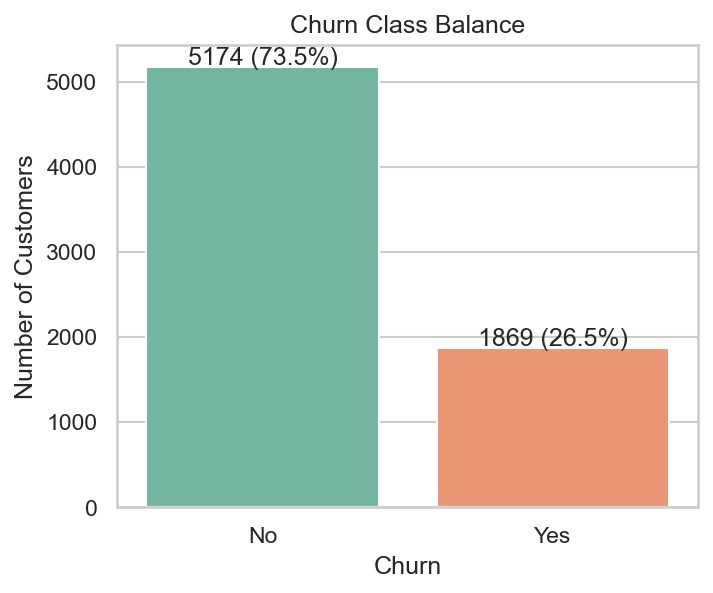

In [5]:
balance = class_balance(df)
print(balance)
print(f"\nChurn rate: {balance.loc['Yes', 'pct']}% - imbalanced. "
      "Report PR-AUC and recall alongside AUC-ROC, not accuracy alone.")
display(Image(str(FIGURES_DIR / "class_balance.png")))

## 3. Churn rate by segment\n\nChurn **rate** per category (not raw counts) for the segments called out in `CLAUDE.md`.

Churn rate by Contract:


,Contract,churn_rate,customers
0,Month-to-month,42.71,3875
1,One year,11.27,1473
2,Two year,2.83,1695


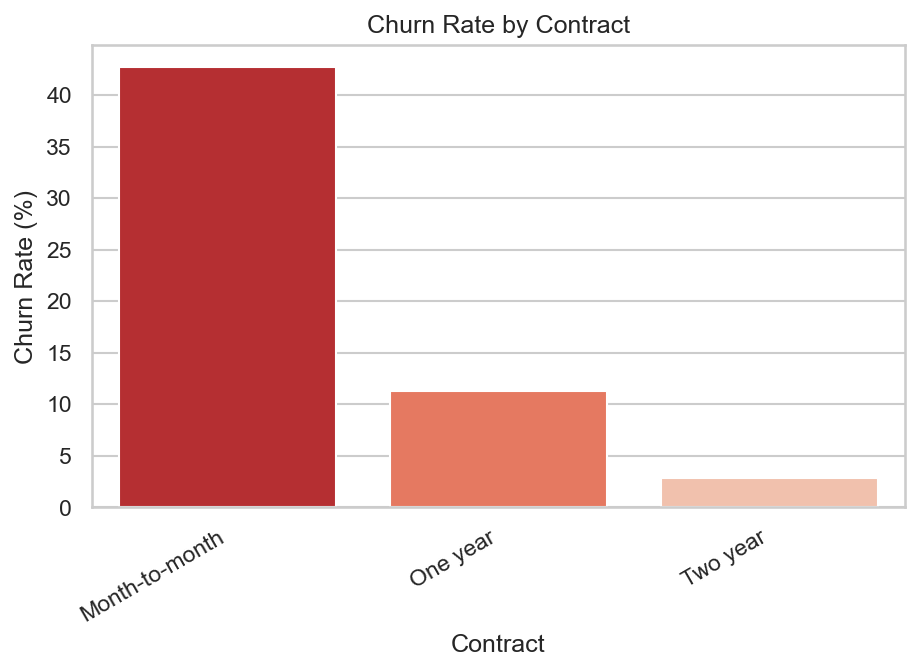

In [6]:
print("Churn rate by Contract:")
display(churn_rate_by_segment(df, "Contract"))
display(Image(str(FIGURES_DIR / "churn_rate_by_Contract.png")))

Churn rate by InternetService:


,InternetService,churn_rate,customers
0,Fiber optic,41.89,3096
1,DSL,18.96,2421
2,No,7.40,1526


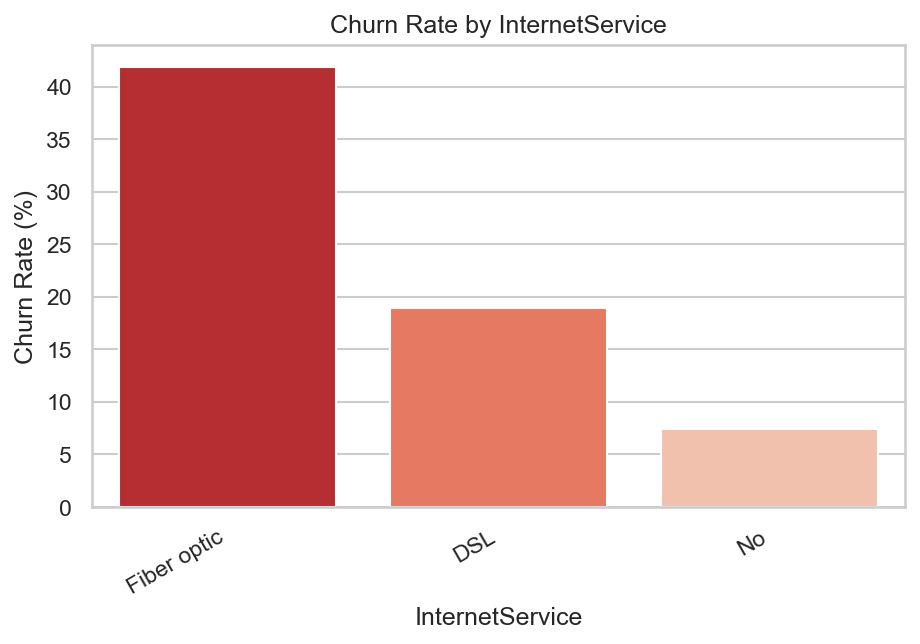

In [7]:
print("Churn rate by InternetService:")
display(churn_rate_by_segment(df, "InternetService"))
display(Image(str(FIGURES_DIR / "churn_rate_by_InternetService.png")))

Churn rate by PaymentMethod:


,PaymentMethod,churn_rate,customers
0,Electronic check,45.29,2365
1,Mailed check,19.11,1612
2,Bank transfer (automatic),16.71,1544
3,Credit card (automatic),15.24,1522


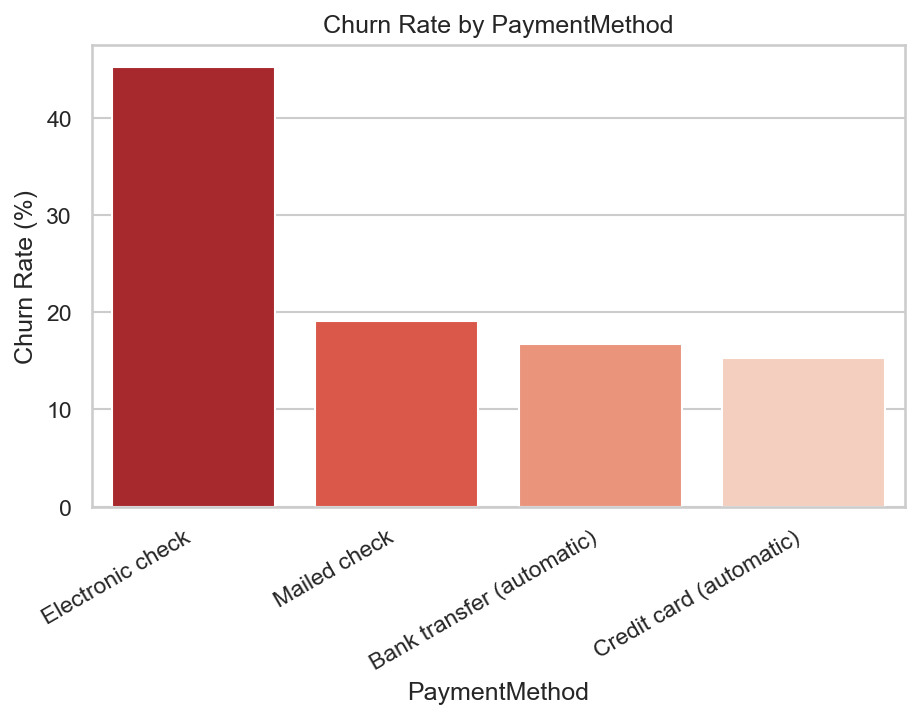

In [8]:
print("Churn rate by PaymentMethod:")
display(churn_rate_by_segment(df, "PaymentMethod"))
display(Image(str(FIGURES_DIR / "churn_rate_by_PaymentMethod.png")))

Churn rate by TechSupport:


,TechSupport,churn_rate,customers
0,No,41.64,3473
1,Yes,15.17,2044
2,No internet service,7.40,1526


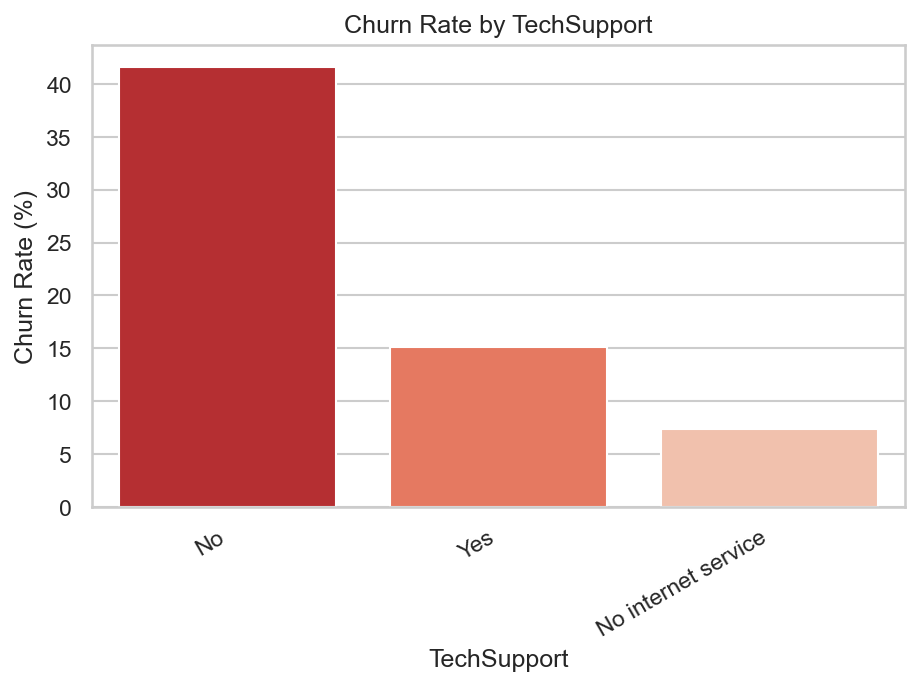

In [9]:
print("Churn rate by TechSupport:")
display(churn_rate_by_segment(df, "TechSupport"))
display(Image(str(FIGURES_DIR / "churn_rate_by_TechSupport.png")))

Churn rate by SeniorCitizen:


,SeniorCitizen,churn_rate,customers
0,Yes,41.68,1142
1,No,23.61,5901


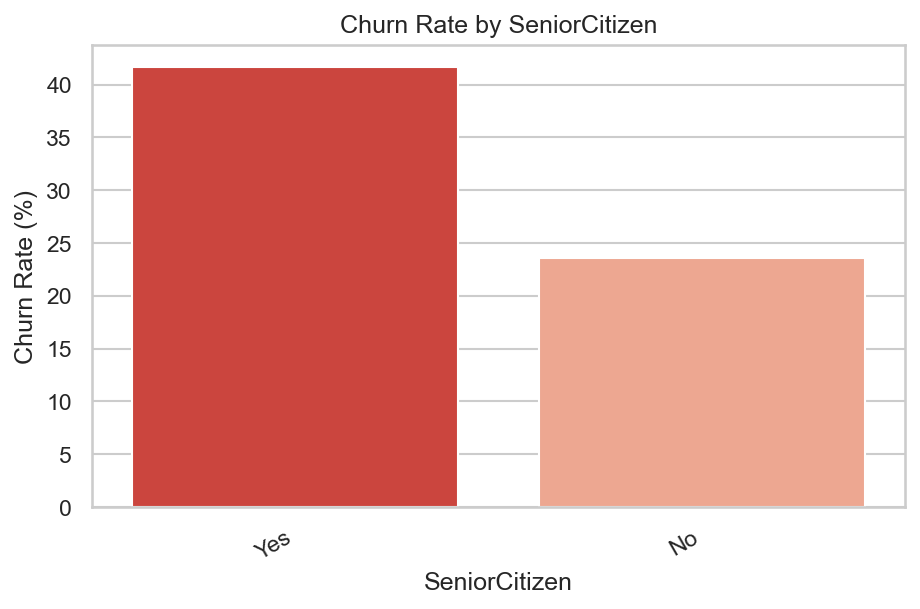

In [10]:
print("Churn rate by SeniorCitizen:")
display(churn_rate_by_segment(df, "SeniorCitizen"))
display(Image(str(FIGURES_DIR / "churn_rate_by_SeniorCitizen.png")))

## 4. Tenure distribution — overall and by churn

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Mean tenure, churned vs retained:
Churn
Retained    37.6
Churned     18.0
Name: tenure, dtype: float64


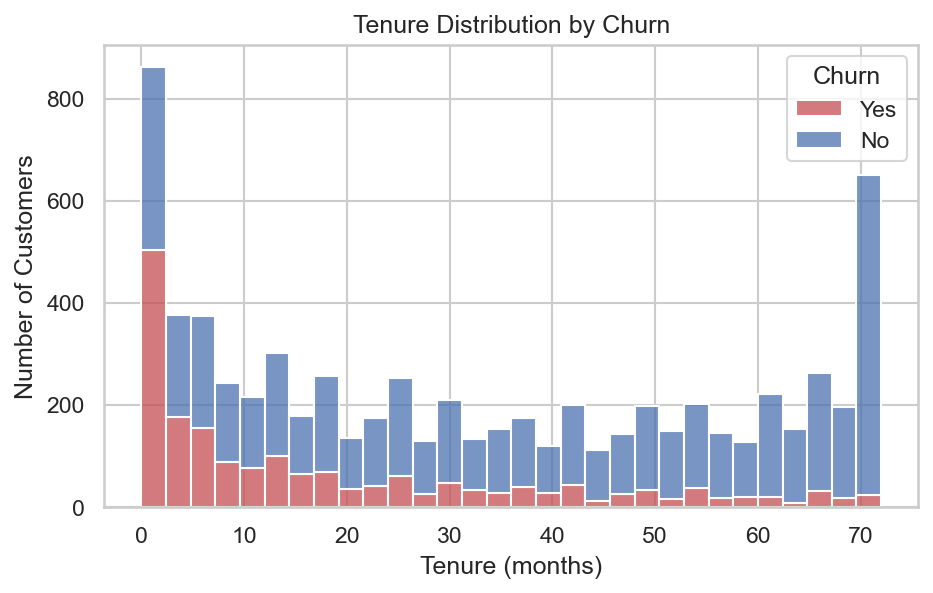

In [11]:
print(df["tenure"].describe())
print("\nMean tenure, churned vs retained:")
print(df.groupby(TARGET_COLUMN)["tenure"].mean().rename({0: "Retained", 1: "Churned"}).round(1))
display(Image(str(FIGURES_DIR / "tenure_distribution.png")))

## 5. MonthlyCharges and TotalCharges by churn

          MonthlyCharges  TotalCharges
Churn                                 
Retained           61.27       2549.91
Churned            74.44       1531.80


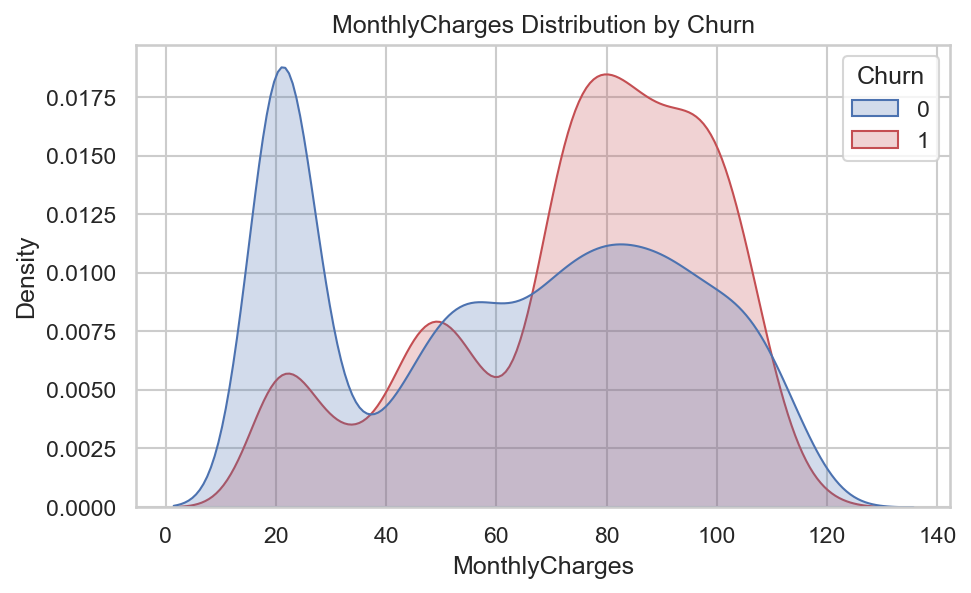

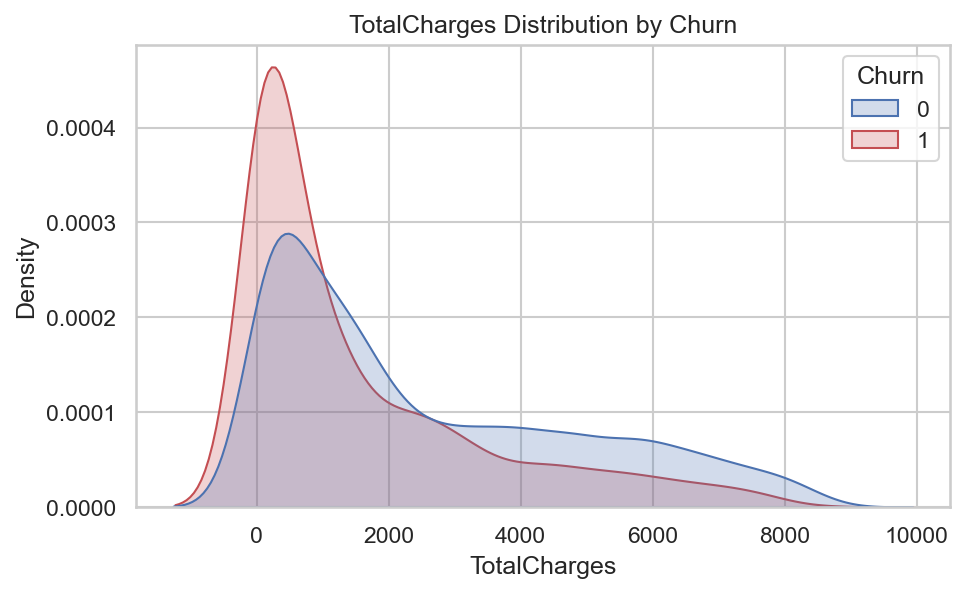

In [12]:
print(df.groupby(TARGET_COLUMN)[["MonthlyCharges", "TotalCharges"]].mean()
      .rename(index={0: "Retained", 1: "Churned"}).round(2))
display(Image(str(FIGURES_DIR / "monthlycharges_distribution.png")))
display(Image(str(FIGURES_DIR / "totalcharges_distribution.png")))

## 6. Correlation between numeric features and churn

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.00,0.25,0.83,-0.35
MonthlyCharges,0.25,1.00,0.65,0.19
TotalCharges,0.83,0.65,1.00,-0.20
Churn,-0.35,0.19,-0.20,1.00


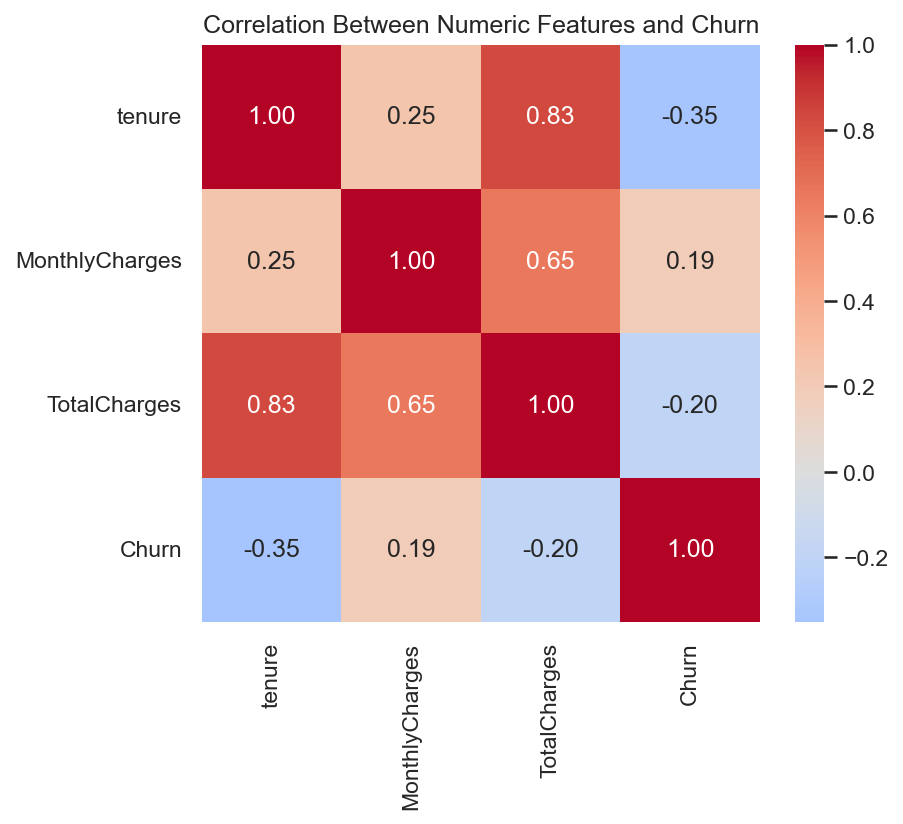

In [13]:
display(df[NUMERIC_COLUMNS + [TARGET_COLUMN]].corr().round(2))
display(Image(str(FIGURES_DIR / "correlation_heatmap.png")))

## 7. Regenerate all KPI charts (idempotent)

In [14]:
paths = generate_all_figures(df)
print(f"Saved {len(paths)} figures to {FIGURES_DIR}")

Saved 10 figures to C:\Users\gozep\OneDrive\Desktop\RetainIQ\reports\figures


## Key findings

- **Class imbalance:** Churn is 26.5% Yes / 73.5% No. Accuracy is not a usable
  headline metric here — the notebook and future model evaluation use PR-AUC
  and recall alongside AUC-ROC.
- **Contract type is the strongest single driver:** month-to-month customers
  churn at 42.7% vs 11.3% (one-year) and 2.8% (two-year). This matches the
  documented signal and is the clearest retention lever — incentivize term
  contracts.
- **Tenure and churn are inversely related:** churned customers average 18.0
  months of tenure vs 37.6 for retained customers; churn risk is heavily front
  -loaded into the first year, pointing at onboarding as a lever.
- **Missing tech/security support tracks with churn:** customers with no
  TechSupport churn at 41.6% vs 15.2% with it — an upsell/retention offer
  candidate.
- **Fiber optic internet churns most:** 41.9% vs 19.0% (DSL) and 7.4% (no
  internet) — worth a service-quality or pricing investigation for fiber
  customers.
- **Electronic check payers churn most:** 45.3% vs 15–19% for automatic/mailed
  payment methods — nudging these customers to autopay is a plausible lever.
- **Senior citizens churn more:** 41.7% vs 23.6% for non-seniors.
- **MonthlyCharges correlates positively with churn, TotalCharges negatively**
  (TotalCharges is confounded with tenure — long-tenured customers accumulate
  higher totals but churn less).

These line up with the sanity-check table in `CLAUDE.md` — no leakage red
flags, and if these signals disappear from the Phase 3 SHAP output, treat that
as a bug to investigate, not a modeling choice.
